In [29]:
import sys
from pathlib import Path

# Note: Will need to move HeFESTo_functions.py to nMELTS/utils so it will be ported properly. 

# Handle both notebook and script contexts
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook context
    repo_root = Path.cwd().parent

# Add both src and src/nMELTS to path
src_root = repo_root / "src"
nmelts_root = src_root / "nMELTS"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
if str(nmelts_root) not in sys.path:
    sys.path.insert(0, str(nmelts_root))

# Import utilities and API
from nMELTS.utils.math_utils import grid_sample, grid_sample_explicit
from nMELTS.engine.API import HeFESToAPI, HeFESToEmulatorCPU, HeFESToEmulatorGPU

print("Imports successful!")
print(f"Repository root: {repo_root}")
print(f"nMELTS root: {nmelts_root}")

# Check emulator availability
if HeFESToEmulatorCPU is None:
    print("\nNote: Pre-instantiated emulators not available (model files missing).")
    print("Create HeFESToAPI instances with valid model paths when needed.")
else:
    print("\nEmulators available:")
    print(f"  - HeFESToEmulatorCPU")
    print(f"  - HeFESToEmulatorGPU")


Imports successful!
Repository root: c:\Git_Repositories\nMELTS
nMELTS root: c:\Git_Repositories\nMELTS\src\nMELTS

Emulators available:
  - HeFESToEmulatorCPU
  - HeFESToEmulatorGPU


In [ ]:
# HeFESTo PS Phase Diagram Demo - Load Simulations

import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Get repo root (from cell 1 setup)
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    repo_root = Path.cwd().parent

# Add builder path for HeFESTo functions
builder_root = repo_root / "src" / "builder"
sys.path.insert(0, str(builder_root))

from HeFESTo.HeFESTo_functions import extract_bulk_properties_from_simulation_dir

# Define compositions for reference
harzburgite = {
    'Si': 3.57887,
    'Mg': 5.64233,
    'Fe': 0.58052,
    'Ca': 0.07969,
    'Al': 0.09740,
    'Na': 0.00160,
    'Cr': 0.01960,
    'O': 13.63947
}

DMM = {
    'Si': 3.79222,
    'Mg': 4.88475,
    'Fe': 0.57874,
    'Ca': 0.28734,
    'Al': 0.39685,
    'Na': 0.02197,
    'Cr': 0.03813,
    'O': 14.00450
}

basalt = {
    'Si': 4.61116,
    'Mg': 1.33197,
    'Fe': 0.61701,
    'Ca': 1.22855,
    'Al': 1.81090,
    'Na': 0.39533,
    'Cr': 0.00508,
    'O': 15.35841
}

# Load HeFESTo PS simulations - use absolute paths
hefesto_workspace = repo_root / "data" / "HeFESToWorkspace"








































    print(f"  Description:\n{df.describe().to_string()}")    print(f"  T range: {df['T(K)'].min():.0f} - {df['T(K)'].max():.0f} K")    print(f"  P range: {df['P(GPa)'].min():.2f} - {df['P(GPa)'].max():.2f} GPa")    print(f"  Shape: {df.shape}")    print(f"\n{sim_name}:")for sim_name, df in sim_tables.items():print("="*70)print("SUMMARY OF LOADED SIMULATIONS")print("="*70)# Display summary        print(f"ERROR loading {sim_name}: {e}\n")    except Exception as e:        print()        print(f"  -> Columns: {list(df.columns)[:8]}...")        print(f"  -> Loaded {len(df)} rows")        sim_tables[sim_name] = df        df = pd.concat([base_df, component_df], axis=1) #bulk_df,            component_df[f'comp_{comp_name}'] = np.asarray(props['component_moles'][:, i]).reshape(n_rows)        for i, comp_name in enumerate(props['component_names']):        component_df = pd.DataFrame(index=base_df.index)            bulk_df = pd.DataFrame(bulk_values, columns=bulk_property_names, index=base_df.index)"""                )                    f"expected {bulk_values.shape[1]}, got {len(bulk_property_names)}"                    f"bulk_property_names length mismatch for {sim_name}: "                raise ValueError(            if len(bulk_property_names) != bulk_values.shape[1]:            bulk_property_names = [str(name) for name in props['bulk_property_names']]                )                    f"expected {n_rows}, got {bulk_values.shape[0]}"


SyntaxError: unterminated string literal (detected at line 141) (1485946737.py, line 141)

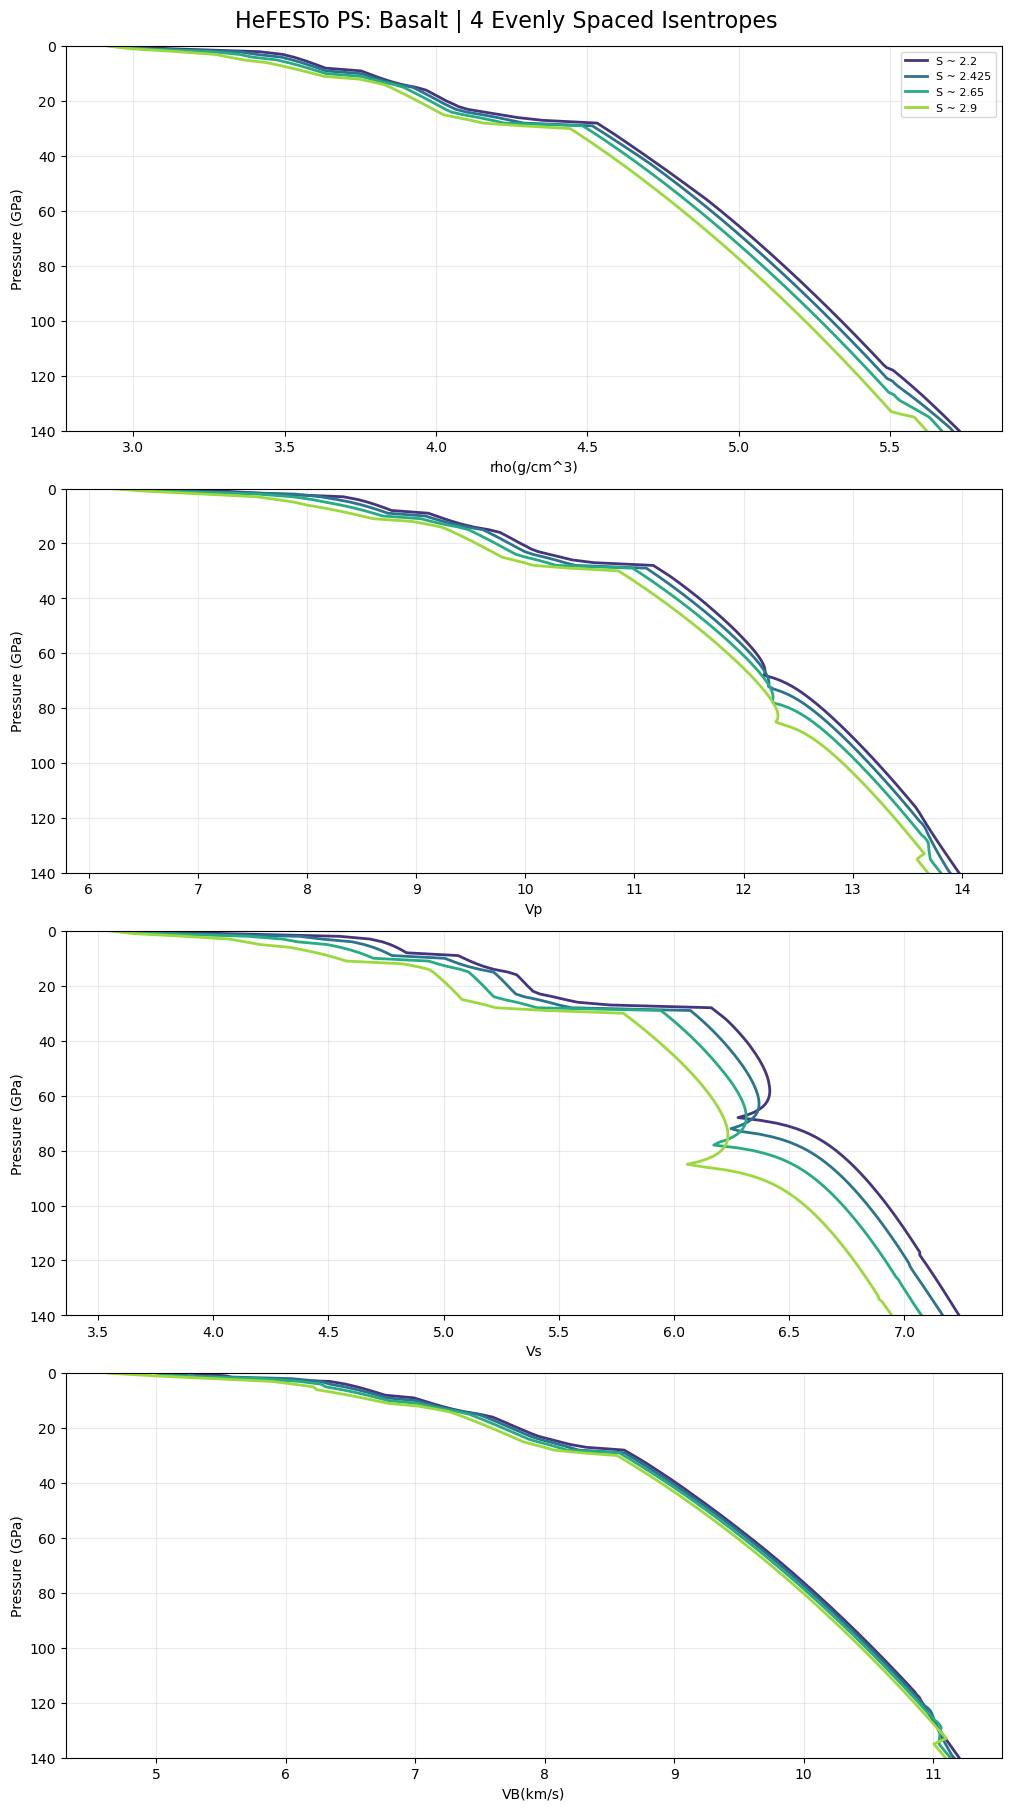

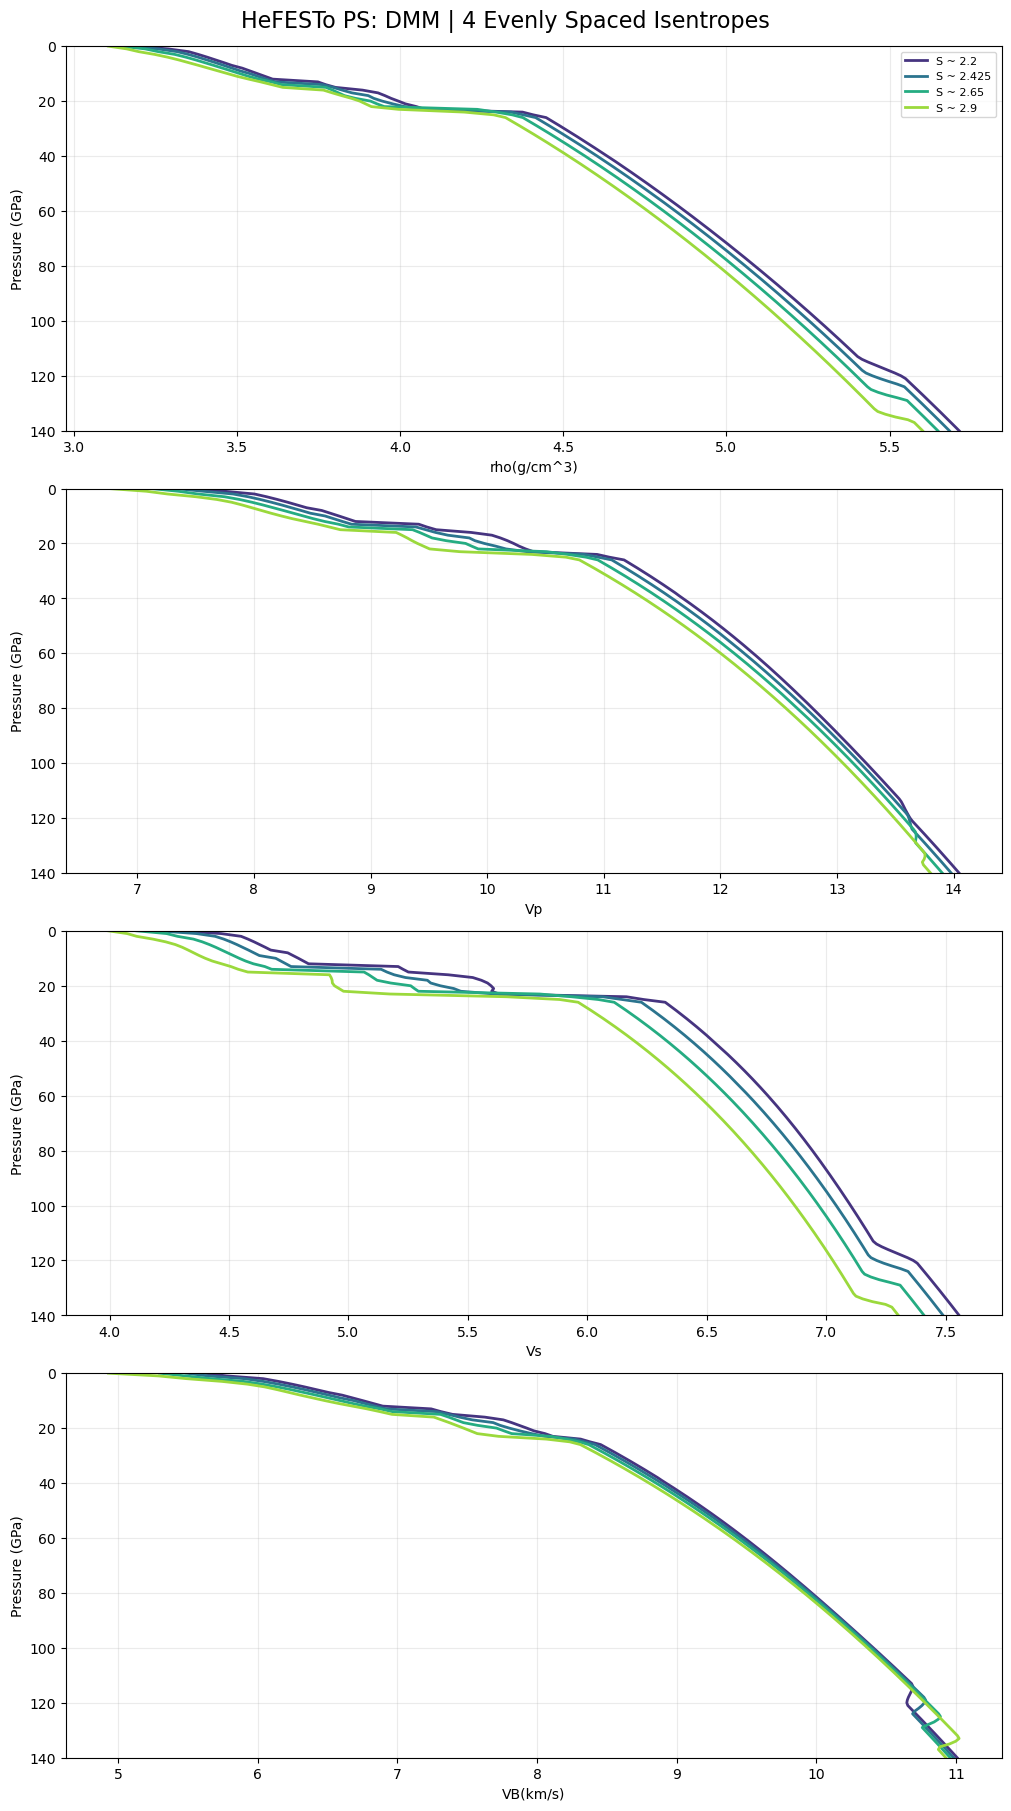

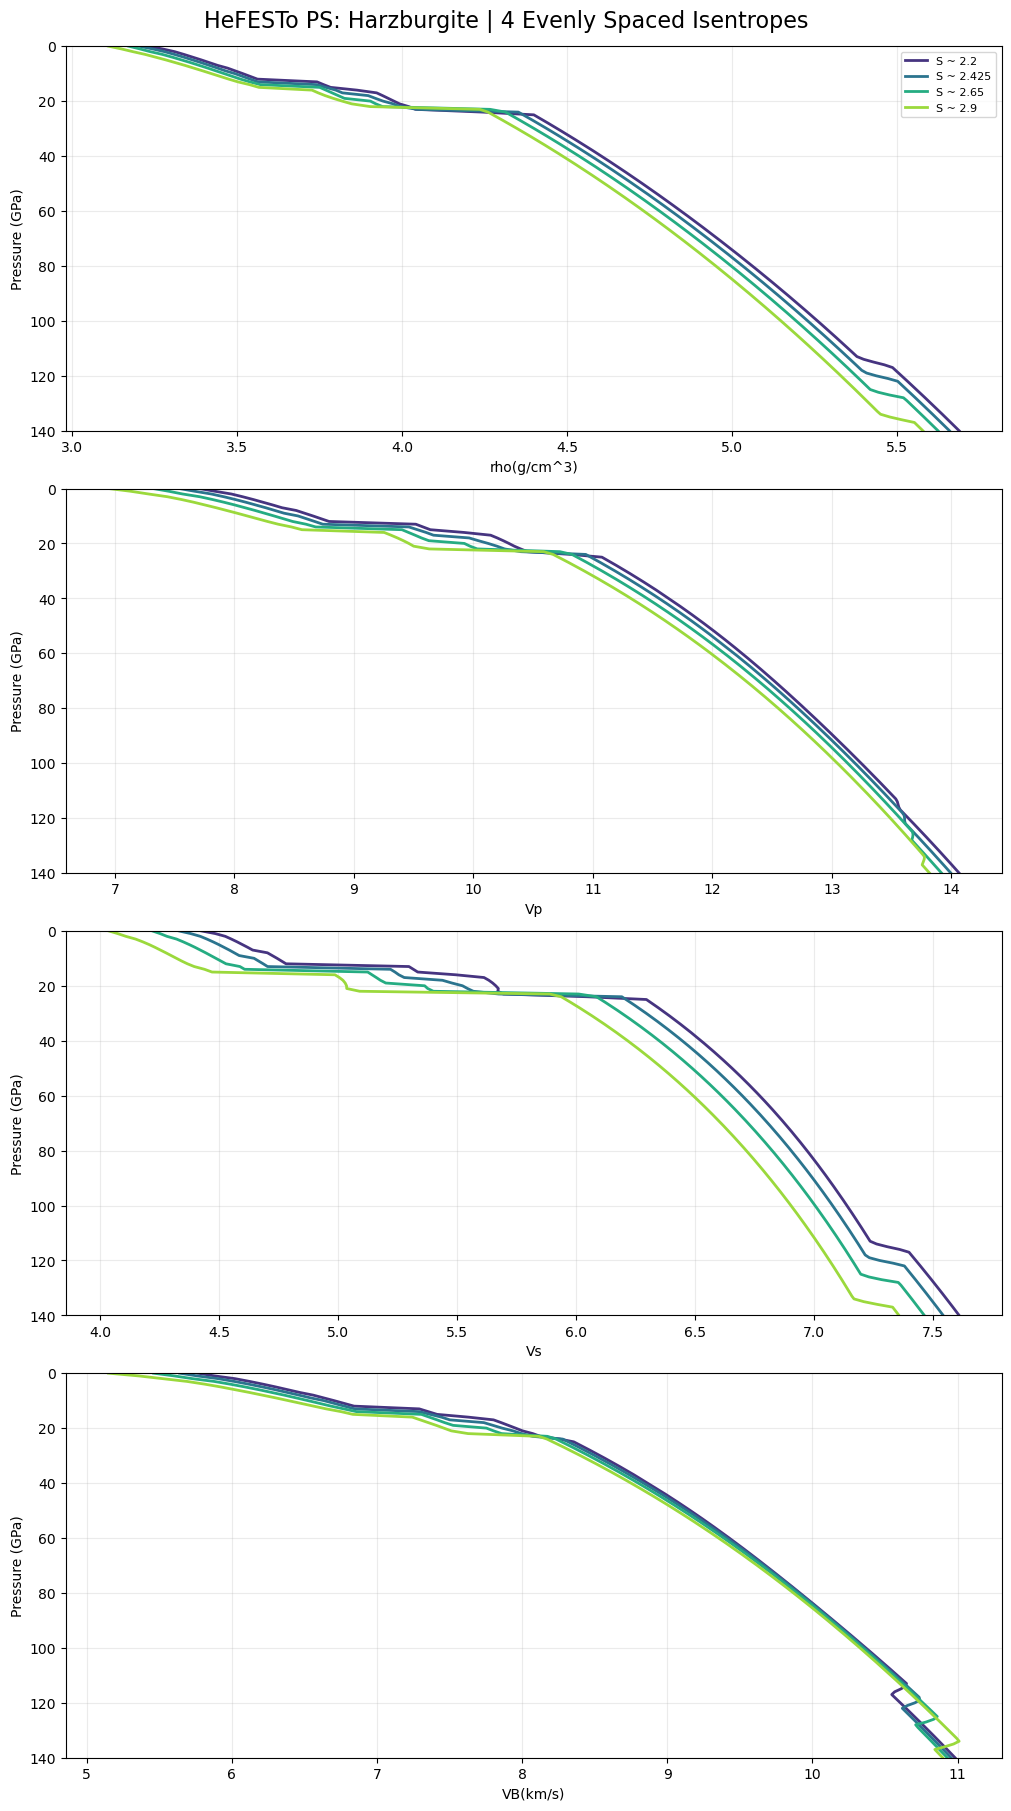

In [31]:
# Plot 5 properties for each composition in a separate 5x1 figure.
# Each composition has 29 isentropes sampled over 141 pressure points from 0 to 140 GPa.
# We select 4 evenly spaced isentropes per composition and plot property (x-axis)
# versus pressure (inverted y-axis).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'sim_tables' not in globals():
    raise RuntimeError('Cell 2 must be run first so sim_tables is available.')

composition_order = ['basalt_PS', 'DMM_PS', 'harzburgite_PS']
composition_titles = {
    'basalt_PS': 'Basalt',
    'DMM_PS': 'DMM',
    'harzburgite_PS': 'Harzburgite',
}

property_specs = [
    ('rho(g/cm^3)', ['rho(g/cm^3)', 'density']),
    ('Vp', ['Vp', 'VP(km/s)', 'vp']),
    ('Vs', ['Vs', 'VS(km/s)', 'vs']),
    ('VB(km/s)', ['VB(km/s)', 'bulk_velocity']),
]


def _resolve_column(df, candidates):
    lower_map = {str(col).lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
        lower_candidate = str(candidate).lower()
        if lower_candidate in lower_map:
            return lower_map[lower_candidate]
    raise KeyError(f'Could not resolve any of {candidates} from columns: {list(df.columns)}')


for sim_name in composition_order:
    if sim_name not in sim_tables:
        raise KeyError(f'Missing table for {sim_name}')

    df = sim_tables[sim_name].copy().reset_index(drop=True)
    pressure_col = _resolve_column(df, ['P(GPa)', 'Pressure', 'pressure'])
    entropy_col = _resolve_column(df, ['entropy', 'Entropy', 'S(J/g/K)', 'S'])

    n_pressure_points = int(pd.to_numeric(df[pressure_col], errors='coerce').nunique(dropna=True))
    if n_pressure_points <= 1 or len(df) % n_pressure_points != 0:
        raise ValueError(
            f'Could not infer isentrope block size for {sim_name}: '
            f'len(df)={len(df)}, unique pressures={n_pressure_points}'
        )

    n_isentropes = len(df) // n_pressure_points
    selected_isentropes = np.linspace(0, n_isentropes - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))

    fig, axes = plt.subplots(
        nrows=len(property_specs),
        ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    plotted_isentropes = []

    for row_idx, (property_name, candidates) in enumerate(property_specs):
        ax = axes[row_idx]
        property_col = _resolve_column(df, candidates)

        for iso_idx, isentrope_idx in enumerate(selected_isentropes):
            plotted_isentropes.append(df[entropy_col].iloc[isentrope_idx*n_pressure_points])
            start = isentrope_idx * n_pressure_points
            end = start + n_pressure_points
            chunk = df.iloc[start:end][[pressure_col, property_col, entropy_col]].copy()
            chunk = chunk.sort_values(pressure_col)

            entropy_value = float(pd.to_numeric(chunk[entropy_col], errors='coerce').mean())
            ax.plot(
                chunk[property_col],
                chunk[pressure_col],
                color=line_colors[iso_idx],
                linewidth=2.0,
                label=f'S ~ {entropy_value:.4g}',
            )

        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(property_name)
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')

    fig.suptitle(
        f"HeFESTo PS: {composition_titles.get(sim_name, sim_name)} | 4 Evenly Spaced Isentropes",
        fontsize=16,
    )
    plt.show()


In [16]:
print(entropy_col)
df[entropy_col].iloc[isentrope_idx*n_pressure_points]

S(J/g/K)


2.2

In [4]:
compositions = {'basalt': basalt, 'DMM': DMM, 'harzburgite': harzburgite}

pressures = np.linspace(0.0, 140.0, 141).astype(np.float32)  # GPa grid used for emulator adiabats
entropies = np.unique(plotted_isentropes)  # J/g/K grid for isentropes


for name, comp in compositions.items(): 
    headers = []
    print(f"\n{name} composition: {comp}")
    comp_array = np.zeros((1, len(basalt)), dtype=np.float32)
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
    input_grid = grid_sample_explicit([entropies, pressures], comp_array)

    headers = ['S(J/g/K)(System_main)', 'P(GPa)(System_main)'] + headers
    #features_tensor = HeFESToEmulatorCPU.parse_input(input_grid, headers=headers)
    bulk_tensor, names = HeFESToEmulatorCPU.get_physub_bulk_matrix(input_grid, headers=headers)


basalt composition: {'Si': 4.61116, 'Mg': 1.33197, 'Fe': 0.61701, 'Ca': 1.22855, 'Al': 1.8109, 'Na': 0.39533, 'Cr': 0.00508, 'O': 15.35841}


AttributeError: 'Tensor' object has no attribute 'astype'

In [6]:
for i, name in enumerate(names):
    print(f"{i}: {name}")
    print(bulk_tensor[::100, i])


0: density
tensor([4.9520e+13, 4.9530e+13, 4.9530e+13, 4.9530e+13, 4.9530e+13, 4.9530e+13])
1: K_Reuss
tensor([0., 0., 0., 0., 0., 0.])
2: K_Voigt
tensor([0., 0., 0., 0., 0., 0.])
3: K_Hill
tensor([0., 0., 0., 0., 0., 0.])
4: G_Reuss
tensor([0., 0., 0., 0., 0., 0.])
5: G_Voigt
tensor([0., 0., 0., 0., 0., 0.])
6: G_Hill
tensor([0., 0., 0., 0., 0., 0.])
7: Vb
tensor([0., 0., 0., 0., 0., 0.])
8: Vs
tensor([0., 0., 0., 0., 0., 0.])
9: Vp
tensor([0., 0., 0., 0., 0., 0.])
10: Vd
tensor([1.0000e-04, 1.0000e-04, 1.0000e-04, 1.0000e-04, 1.0000e-04, 1.0000e-04])
11: Cp
tensor([0., 0., 0., 0., 0., 0.])
12: Cv
tensor([0., 0., 0., 0., 0., 0.])
13: alpha
tensor([0., 0., 0., 0., 0., 0.])
14: gamma
tensor([0., 0., 0., 0., 0., 0.])
15: entropy
tensor([0., 0., 0., 0., 0., 0.])
16: enthalpy
tensor([0., 0., 0., 0., 0., 0.])
17: Gibbs
tensor([0., 0., 0., 0., 0., 0.])


In [27]:
import burnman
from src.nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

mineral_list = dir(burnman.minerals.SLB_2024)

shorthands = list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())
longhands = list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys())

compnames = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_names

BurnMan_minerals = dir(burnman.minerals.SLB_2024)

mineral= np.array()
for mineral, idx in HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_indices.items():
    print(f"Emulator {mineral}: {compnames[idx]}")
    MinComps = compnames[idx]
    try:
        BurnMan_mineral = getattr(burnman.minerals.SLB_2024, mineral)()
        print(f"{mineral} present in BurnMan!")
        subcomps = getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae
        for sc in MinComps:
            contains = sc in 
            print(f"  - {sc}")


    for mineral in mineral_list:
        print(mineral)
        try:
            endmember_names = getattr(burnman.minerals.SLB_2022, mineral)().endmember_names
            for i, name in enumerate(endmember_names):
                print(f"{endmember_names[i]}: {getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae[i]}")
        except:
            try:        
                print(f"Formula: {getattr(burnman.minerals.SLB_2024, mineral)().formula}")
                print(f"Pure Phase!")
            except:
                print(f"{mineral} is not a material!")
        print("\n\n###############################\n")


plagioclase: ['anorthite' 'albite']
spinel: ['spinel' 'hercynite' 'magnetite' 'picro-chromite']
olivine: ['forsterite' 'fayalite']
wadsleyite: ['mg-wadsleyite' 'fe-wadsleyite']
ringwoodite: ['mg-ringwoodite' 'fe-ringwoodite']
orthopyroxene: ['enstatite' 'ferrosilite' 'mg-tschermaks' 'ortho-diopside']
clinopyroxene: ['diopside' 'hedenbergite' 'clinoenstatite' 'ca-tschermaks' 'jadeite'
 'acmite']
hp-clinopyroxene: ['hp-clinoenstatite' 'hp-clinoferrosilite']
ca-perovskite: ['ca-perovskite']
akimotoite: ['mg-akimotoite' 'fe-akimotoite' 'corundum' 'hematite' 'eskolaite']
garnet: ['pyrope' 'almandine' 'grossular' 'mg-majorite' 'na-majorite' 'andradite'
 'knorringite']
stishovite: ['stishovite']
bridgmanite: ['mg-bridgmanite' 'fe-bridgmanite' 'al-bridgmanite' 'ferric-bridgmanite'
 'ferric-bridgmanite-ls' 'ferric-al-bridgmanite' 'cr-bridgmanite']
post-perovskite: ['mg-post-perovskite' 'fe-post-perovskite' 'al-post-perovskite'
 'ferric-post-perovskite' 'cr-post-perovskite']
ferropericlase: ['pe

In [33]:
burnman.minerals.SLB_2022.sp().formula

{'Mg': 4.0, 'Al': 8.0, 'O': 16.0}

In [ ]:
import burnman

mineral_list = dir(burnman.minerals.SLB_2024)

for mineral in mineral_list:
    print(mineral)
    try:
        endmember_names = getattr(burnman.minerals.SLB_2024, mineral)().endmember_names
        for i, name in enumerate(endmember_names):
            print(f"{endmember_names[i]}: {getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae[i]}")
    except:
        try:        
            print(f"Formula: {getattr(burnman.minerals.SLB_2024, mineral)().formula}")
            print(f"Pure Phase!")
        except:
            print(f"{mineral} is not a material!")
    print("\n\n###############################\n")


{'Ca': 3.0, 'Fe': 2.0, 'Si': 3.0, 'O': 12.0}
{'Ca': 3.0, 'Al': 2.0, 'Si': 3.0, 'O': 12.0}


AsymmetricRegularSolution
AsymmetricRegularSolution is not a material!


###############################

IdealSolution
IdealSolution is not a material!


###############################

Mineral
Mineral is not a material!


###############################

RelaxedSolution
RelaxedSolution is not a material!


###############################

SLB3
SLB3 is not a material!


###############################

SLB3Stishovite
SLB3Stishovite is not a material!


###############################

Solution
Solution is not a material!


###############################

SymmetricRegularSolution
SymmetricRegularSolution is not a material!


###############################

__builtins__
__builtins__ is not a material!


###############################

__cached__
__cached__ is not a material!


###############################

__doc__
__doc__ is not a material!


###############################

__file__
__file__ is not a material!


###############################

__loader__
__loader__ is not a mat

In [19]:
mineral = 'clinopyroxene'
getattr(burnman.minerals.SLB_2024, mineral)().endmember_names


['Diopside',
 'Hedenbergite',
 'Clinoenstatite',
 "Lime_Tschermak'",
 'Jadeite',
 'Acmite']

In [ ]:
# Run after restarting kernel and re-running cell 1 (imports + sim_tables)
import numpy as np
import torch
from nMELTS.engine.API import HeFESToAPI
from nMELTS.engine.EOS_arithmetic import compute_physub_bulk_matrix

# Instantiate (CPU)
api = HeFESToEmulatorCPU  # Use pre-instantiated CPU emulator; will raise error if model files not found

pressures = np.linspace(0.0, 140.0, 141).astype(np.float32)  # GPa grid used for emulator adiabats

# Mapping from plotted property name -> compute_physub selector
prop_to_selector = {
    'rho(g/cm^3)': 'density',
    'Vp': 'Vp',
    'Vs': 'Vs',
    'VB(km/s)': 'Vb',
}

# reuse helpers from notebook
def _resolve_column(df, candidates):
    lower_map = {str(col).lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
        if str(candidate).lower() in lower_map:
            return lower_map[str(candidate).lower()]
    raise KeyError(f'Could not resolve any of {candidates} from columns: {list(df.columns)}')

# loop compositions and replot (same layout as tutorial plotting, but add emulator markers)
composition_order = ['basalt_PS', 'DMM_PS', 'harzburgite_PS']
property_specs = [
    ('rho(g/cm^3)', ['rho(g/cm^3)', 'density']),
    ('Vp', ['Vp', 'VP(km/s)', 'vp']),
    ('Vs', ['Vs', 'VS(km/s)', 'vs']),
    ('VB(km/s)', ['VB(km/s)', 'bulk_velocity']),
]

import matplotlib.pyplot as plt

for sim_name in composition_order:
    df = sim_tables[sim_name].copy().reset_index(drop=True)
    pressure_col = _resolve_column(df, ['P(GPa)', 'Pressure', 'pressure'])
    entropy_col = _resolve_column(df, ['entropy', 'Entropy', 'S(J/g/K)', 'S'])
    t_col = _resolve_column(df, ['T(K)', 'Temperature', 'temperature'])

    n_pressure_points = int(pd.to_numeric(df[pressure_col], errors='coerce').nunique(dropna=True))
    n_isentropes = len(df) // n_pressure_points
    selected_isentropes = np.linspace(0, n_isentropes - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))

    fig, axes = plt.subplots(nrows=len(property_specs), ncols=1, figsize=(10, 18), sharey=True, constrained_layout=True)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for row_idx, (property_name, candidates) in enumerate(property_specs):
        ax = axes[row_idx]
        property_col = _resolve_column(df, candidates)

        for iso_idx, isentrope_idx in enumerate(selected_isentropes):
            start = isentrope_idx * n_pressure_points
            end = start + n_pressure_points
            chunk = df.iloc[start:end][[pressure_col, property_col, entropy_col, t_col] + [c for c in df.columns if str(c).startswith('comp_')]].copy()
            chunk = chunk.sort_values(pressure_col)
            entropy_value_g = float(pd.to_numeric(chunk[entropy_col], errors='coerce').mean())  # J/g/K

            # plot Fortran line
            ax.plot(chunk[property_col], chunk[pressure_col], color=line_colors[iso_idx], linewidth=2.0)

            # Build single-row feature dict from first row of this isentrope (representative state)
            rep = chunk.iloc[0]
            feat = {}
            # Temperature and Pressure (use canonical labels expected by parse_input)
            feat['T'] = float(rep[t_col])            # will be canonicalized to T(K)(System_main)
            feat['P'] = float(rep[pressure_col])     # will be canonicalized to P(GPa)(System_main)

            # Compose component values from comp_* columns
            comp_cols = [c for c in chunk.columns if str(c).startswith('comp_')]
            comp_names = [c.replace('comp_', '') for c in comp_cols]
            comp_vals = np.array([float(rep[c]) for c in comp_cols], dtype=np.float32)

            # Put composition into feat dict (parser will detect and handle)
            for name, val in zip(comp_names, comp_vals):
                feat[name] = float(val)

            # Parse features into emulator ordering (returns torch tensor on api.device)
            features_tensor = api.parse_input(feat, headers=list(feat.keys()))
            # Create design matrix of (S,P) states at requested pressures
            iso_feat_names = list(api.isentropic_emulator.ml_indexer.featureNames)
            S_idx = iso_feat_names.index('S(J/g/K)(System_main)')
            pressure_idx = iso_feat_names.index('P(GPa)(System_main)')
            design = api._create_iso_design_matrix(features_tensor, pressures, S_idx, pressure_idx, potential_temperatures=None)
            design_t = torch.as_tensor(design, dtype=torch.float32, device=api.device)

            # Forward staged through isentropic emulator to get component moles
            iso_out = api._staged_forward(api.isentropic_emulator.forwardMB, design_t, batch_size=2**12, Normalize=True, outputs=['component_moles'])
            # iso_out may be dict or list/tuple: handle both
            if isinstance(iso_out, dict):
                pred_comp_moles = iso_out['component_moles']
            elif isinstance(iso_out, (list, tuple)):
                pred_comp_moles = iso_out[0]
            else:
                pred_comp_moles = iso_out

            # Ensure tensor on CPU for compute_physub_bulk_matrix and shape (n_press, C)
            pred_comp_moles = pred_comp_moles.detach().cpu().float()

            # Compute bulk properties (density, Vp, Vs, Vb, etc.)
            molar_mass_tensor = ctx.formula_mass_g_mol.to(pred_comp_moles.device).float()
            selectors = [prop_to_selector[p[0]] for p in property_specs]  # not used here; we'll request only the property needed
            # Request the specific selector for this plotted property
            selector = prop_to_selector[property_name]
            bulk_tensor, names = compute_physub_bulk_matrix(pred_comp_moles, molar_mass_tensor, selectors=[selector], hefesto_context=ctx)
            # bulk_tensor shape (n_press, 1)
            x_pred = bulk_tensor.detach().cpu().numpy().reshape(-1)
            y_pred = pressures  # np array

            # Overlay markers
            ax.scatter(x_pred, y_pred, marker='o', color='k', s=20, zorder=10)

        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(property_name)
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend([f'Isentrope lines (fortran)'], fontsize=8, loc='best')

    fig.suptitle(f"HeFESTo PS: {sim_name} | 4 Evenly Spaced Isentropes (emulator markers overlaid)", fontsize=14)
    plt.show()

In [ ]:
# BurnMan search (fresh cell) - robustly search emulator components in BurnMan
import burnman
from nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

shorthand_map = HEFESTO_ABBREVIATION_TO_SHORT_NAMES
compnames = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_names
label_indices = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_indices

def _ensure_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    return [x]

for mineral, idx in label_indices.items():
    print("EMULATOR PHASE:", mineral, f"(index={idx})")
    MinComps = _ensure_list(compnames[idx] if idx < len(compnames) else [])
    print("  Emulator components:", MinComps)

    bm_obj = None
    found_ver = None
    for ver in ("SLB_2024", "SLB_2022"):
        module = getattr(burnman.minerals, ver, None)
        if module and hasattr(module, mineral):
            try:
                bm_obj = getattr(module, mineral)()
                found_ver = ver
                break
            except Exception as e:
                bm_obj = None
    if bm_obj is None:
        print("  -> Not found in burnman SLB_2024/2022")
        print("
#"*30 + "
")
        continue
    print(f"  -> Found in burnman.minerals.{found_ver}")
    em_names = getattr(bm_obj, 'endmember_names', []) or []
    em_forms = getattr(bm_obj, 'endmember_formulae', []) or []
    formula = getattr(bm_obj, 'formula', None)
    if em_names:
        print("    endmember_names:", em_names)
    if em_forms:
        print("    endmember_formulae:", em_forms)
    if formula:
        print("    formula:", formula)

    for comp in MinComps:
        print(f"    Searching for component '{comp}':")
        found_any = False
        candidates = {str(comp)}
        if str(comp) in shorthand_map:
            candidates.add(shorthand_map[str(comp)])
        for k, v in shorthand_map.items():
            if str(comp) == v:
                candidates.add(k)
        for cand in list(candidates):
            cand = str(cand)
            if any(cand == str(n) or cand in str(n) for n in em_names):
                print(f"      - matched endmember name: {cand}")
                found_any = True
            if any(cand == str(f) or cand in str(f) for f in em_forms):
                print(f"      - matched endmember formula: {cand}")
                found_any = True
            if formula and cand in str(formula):
                print(f"      - matched phase formula: {cand}")
                found_any = True
        if not found_any:
            print("      - No match in this burnman phase")
    print("
#"*30 + "
")
